# Лабораторная работа — Метод опорных векторов (SVM)

В работе реализованы:

- линейно разделимый SVM;
- soft-margin SVM;
- сравнение QP / SVC / LinearSVC;
- исследование параметра C;
- исследование различных ядер;
- визуализация опорных векторов и разделяющих границ.


In [1]:
import sys

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score

import qpsolvers
from qpsolvers import solve_qp, available_solvers

## Линейно разделимая выборка

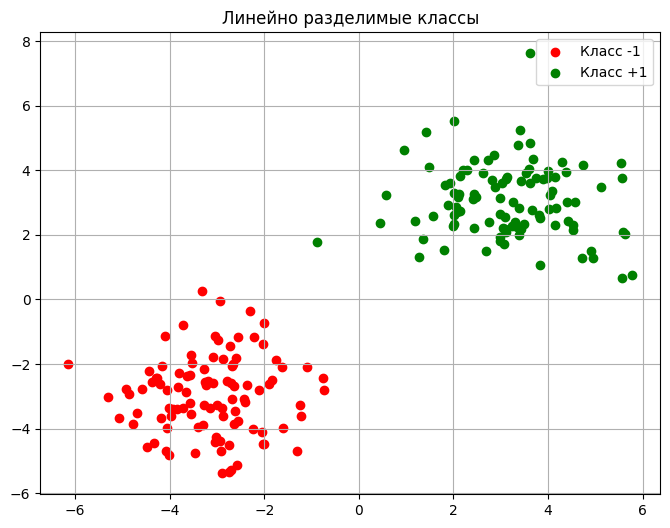

In [2]:
X, y_labels = make_blobs(n_samples=200, centers=[[-3, -3], [3, 3]], cluster_std=1.2, random_state=42)
y = np.where(y_labels == 0, -1.0, 1.0)

X1 = X[y == -1]
X2 = X[y == 1]

plt.figure(figsize=(8, 6))
plt.scatter(X1[:, 0], X1[:, 1], color='red', label='Класс -1')
plt.scatter(X2[:, 0], X2[:, 1], color='green', label='Класс +1')
plt.title('Линейно разделимые классы')
plt.grid(True)
plt.legend()
plt.show()


In [3]:
N = X.shape[0]

K = X @ X.T

P = np.outer(y, y) * K
P += np.eye(N) * 1e-5

q = -np.ones(N)

G = -np.eye(N)
h = np.zeros(N)

A = y.astype(float).reshape(1, -1)
b = np.array([0.0])

alpha = solve_qp(P, q, G, h, A, b, solver='osqp')

if alpha is None:
    raise ValueError("QP solver не нашёл решение")

support_idx = np.where(alpha > 1e-4)[0]
support_vectors = X[support_idx]

w_qp = np.sum((alpha * y)[:, None] * X, axis=0)

support_labels = y[support_idx]

w0_qp = np.mean(support_labels - support_vectors @ w_qp)

print("Количество опорных векторов:", len(support_vectors))
print("w =", w_qp)
print("w0 =", w0_qp)


Количество опорных векторов: 2
w = [0.42832939 0.65031598]
w0 = 0.22718956166331933


c:\Users\Darowiin\AppData\Local\Programs\Python\Python312\Lib\site-packages\qpsolvers\conversions\ensure_sparse_matrices.py:28: SparseConversionWarning: Converted matrix 'P' of your problem to scipy.sparse.csc_matrix to pass it to solver 'osqp'; for best performance, build your matrix as a csc_matrix directly.
  warnings.warn(
c:\Users\Darowiin\AppData\Local\Programs\Python\Python312\Lib\site-packages\qpsolvers\conversions\ensure_sparse_matrices.py:28: SparseConversionWarning: Converted matrix 'G' of your problem to scipy.sparse.csc_matrix to pass it to solver 'osqp'; for best performance, build your matrix as a csc_matrix directly.
  warnings.warn(
c:\Users\Darowiin\AppData\Local\Programs\Python\Python312\Lib\site-packages\qpsolvers\conversions\ensure_sparse_matrices.py:28: SparseConversionWarning: Converted matrix 'A' of your problem to scipy.sparse.csc_matrix to pass it to solver 'osqp'; for best performance, build your matrix as a csc_matrix directly.
  warnings.warn(


In [4]:
svc = SVC(kernel='linear', C=1e6)
svc.fit(X, y)

linear_svc = LinearSVC(C=1e6, loss='hinge', max_iter=100000)
linear_svc.fit(X, y)

w_svc = svc.coef_[0]
w0_svc = svc.intercept_[0]

w_lsvc = linear_svc.coef_[0]
w0_lsvc = linear_svc.intercept_[0]

pred_qp = np.sign(X @ w_qp + w0_qp)
pred_svc = svc.predict(X)
pred_lsvc = linear_svc.predict(X)

error_qp = np.mean(pred_qp != y)
error_svc = np.mean(pred_svc != y)
error_lsvc = np.mean(pred_lsvc != y)

print("=== Ошибки классификации ===")
print(f"QP-SVM: {error_qp:.4f}")
print(f"SVC: {error_svc:.4f}")
print(f"LinearSVC: {error_lsvc:.4f}")


=== Ошибки классификации ===
QP-SVM: 0.0000
SVC: 0.0000
LinearSVC: 0.0000


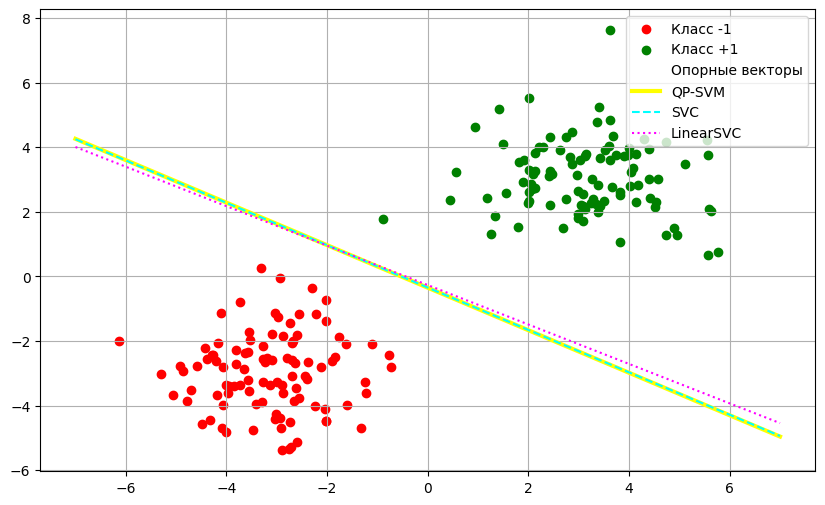

In [5]:
def get_hyperplane_y(x, w, w0):
    return -(w[0] * x + w0) / w[1]

x_vals = np.linspace(-7, 7, 100)

plt.figure(figsize=(10, 6))

plt.scatter(X1[:, 0], X1[:, 1], color='red', label='Класс -1')
plt.scatter(X2[:, 0], X2[:, 1], color='green', label='Класс +1')

plt.scatter(
    support_vectors[:, 0],
    support_vectors[:, 1],
    facecolors='none',
    edgecolors='white',
    s=120,
    linewidths=2,
    label='Опорные векторы'
)

plt.plot(
    x_vals,
    get_hyperplane_y(x_vals, w_qp, w0_qp),
    color='yellow',
    linewidth=3,
    label='QP-SVM'
)

plt.plot(
    x_vals,
    get_hyperplane_y(x_vals, w_svc, w0_svc),
    color='cyan',
    linestyle='--',
    label='SVC'
)

plt.plot(
    x_vals,
    get_hyperplane_y(x_vals, w_lsvc, w0_lsvc),
    color='magenta',
    linestyle=':',
    label='LinearSVC'
)

plt.grid(True)
plt.legend()
plt.show()

## Soft-Margin SVM

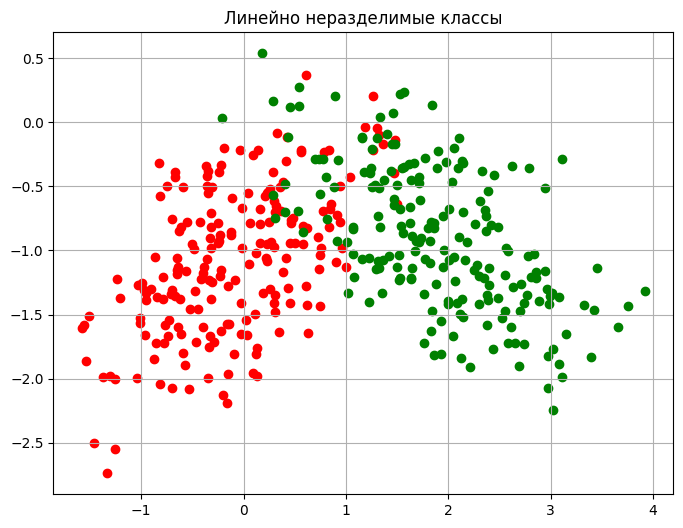

In [18]:
X1_soft = np.load('distrib_uneq_2_[0,-1].npy')
X2_soft = np.load('distrib_uneq_3_[2,-1].npy')

X_soft = np.vstack([X1_soft, X2_soft])

y_soft = np.concatenate([
    -np.ones(X1_soft.shape[0]),
     np.ones(X2_soft.shape[0])
])

X1_soft = X_soft[y_soft == -1]
X2_soft = X_soft[y_soft == 1]

plt.figure(figsize=(8, 6))
plt.scatter(X1_soft[:, 0], X1_soft[:, 1], color='red')
plt.scatter(X2_soft[:, 0], X2_soft[:, 1], color='green')
plt.title('Линейно неразделимые классы')
plt.grid(True)
plt.show()


In [19]:
def solve_soft_margin_qp(X, y, C):

    N = X.shape[0]

    K = X @ X.T

    P = np.outer(y, y) * K
    P += np.eye(N) * 1e-5

    q = -np.ones(N)

    G = np.vstack([
        -np.eye(N),
        np.eye(N)
    ])

    h = np.hstack([
        np.zeros(N),
        np.ones(N) * C
    ])

    A = y.astype(float).reshape(1, -1)
    b = np.array([0.0])

    alpha = solve_qp(P, q, G, h, A, b, solver='osqp')

    if alpha is None:
        raise ValueError("QP solver не нашёл решение")

    support_idx = np.where(alpha > 1e-3)[0]

    w = np.sum((alpha * y)[:, None] * X, axis=0)

    margin_idx = np.where((alpha > 1e-3) & (alpha < C - 1e-3))[0]

    if len(margin_idx) > 0:
        w0 = np.mean(y[margin_idx] - X[margin_idx] @ w)
    else:
        w0 = np.mean(y[support_idx] - X[support_idx] @ w)

    return alpha, w, w0, support_idx


In [20]:
C_values = [0.1, 1, 10]

for C in C_values:

    alpha, w, w0, sv_idx = solve_soft_margin_qp(X_soft, y_soft, C)

    pred = np.sign(X_soft @ w + w0)
    error = np.mean(pred != y_soft)

    print("=" * 40)
    print(f"C = {C}")
    print("Ошибка:", error)
    print("Опорных векторов:", len(sv_idx))
    print("w =", w)
    print("w0 =", w0)


C = 0.1
Ошибка: 0.0925
Опорных векторов: 116
w = [1.62366457 0.34755147]
w0 = -1.1835281623407456
C = 1
Ошибка: 0.1325
Опорных векторов: 88
w = [2.14071196 0.55462391]
w0 = -2.454058697934929
C = 10
Ошибка: 0.1775
Опорных векторов: 194
w = [2.29592256 0.56670337]
w0 = 0.10940521448063495


c:\Users\Darowiin\AppData\Local\Programs\Python\Python312\Lib\site-packages\qpsolvers\conversions\ensure_sparse_matrices.py:28: SparseConversionWarning: Converted matrix 'P' of your problem to scipy.sparse.csc_matrix to pass it to solver 'osqp'; for best performance, build your matrix as a csc_matrix directly.
  warnings.warn(
c:\Users\Darowiin\AppData\Local\Programs\Python\Python312\Lib\site-packages\qpsolvers\conversions\ensure_sparse_matrices.py:28: SparseConversionWarning: Converted matrix 'G' of your problem to scipy.sparse.csc_matrix to pass it to solver 'osqp'; for best performance, build your matrix as a csc_matrix directly.
  warnings.warn(
c:\Users\Darowiin\AppData\Local\Programs\Python\Python312\Lib\site-packages\qpsolvers\conversions\ensure_sparse_matrices.py:28: SparseConversionWarning: Converted matrix 'A' of your problem to scipy.sparse.csc_matrix to pass it to solver 'osqp'; for best performance, build your matrix as a csc_matrix directly.
  warnings.warn(


C = 0.1
Ошибка: 0.0925
Опорных векторов: 116
w = [1.62366457 0.34755147]
w0 = -1.1835281623407456


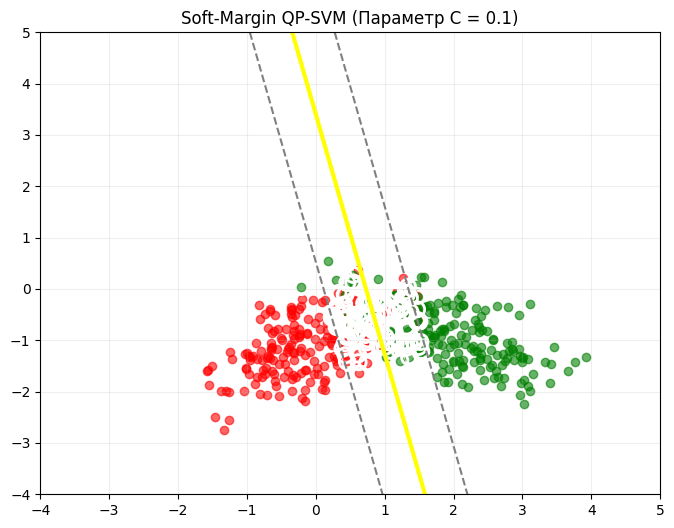

C = 1
Ошибка: 0.1325
Опорных векторов: 88
w = [2.14071196 0.55462391]
w0 = -2.454058697934929


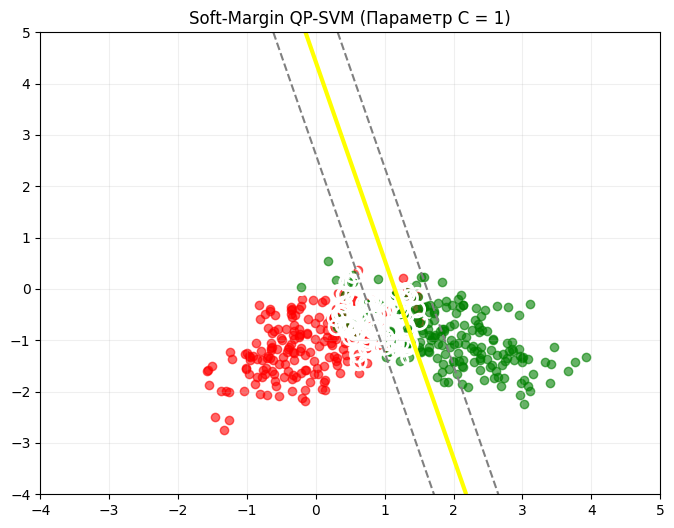

C = 10
Ошибка: 0.1775
Опорных векторов: 194
w = [2.29592256 0.56670337]
w0 = 0.10940521448063495


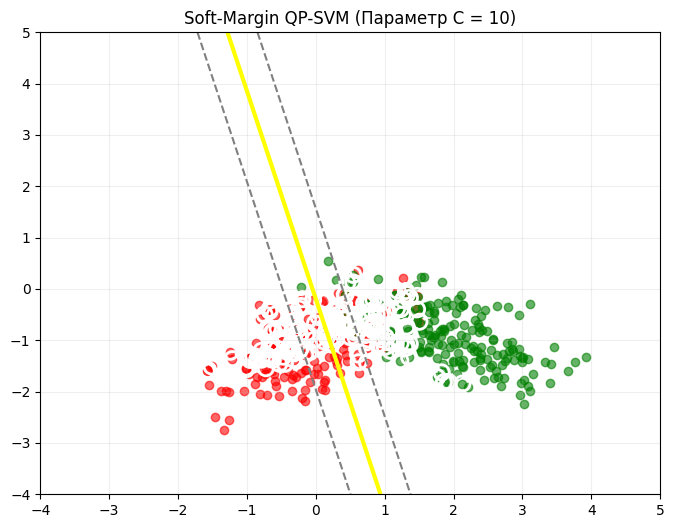

In [21]:
for C in C_values:
    # 1. Решаем задачу
    alpha, w, w0, sv_idx = solve_soft_margin_qp(X_soft, y_soft, C)

    pred = np.sign(X_soft @ w + w0)
    error = np.mean(pred != y_soft)

    # 2. Выводим текст
    print("=" * 40)
    print(f"C = {C}")
    print("Ошибка:", error)
    print("Опорных векторов:", len(sv_idx))
    print("w =", w)
    print("w0 =", w0)

    # 3. СТРОИМ ГРАФИК ДЛЯ КАЖДОГО C
    # Создаем сетку для вычисления функции на всем графике
    xx, yy = np.meshgrid(np.linspace(-4, 5, 200), np.linspace(-4, 5, 200))
    # Считаем уравнение плоскости: W*X + w0
    Z = np.c_[xx.ravel(), yy.ravel()] @ w + w0
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    
    # Рисуем точки классов
    plt.scatter(X1_soft[:, 0], X1_soft[:, 1], color='red', alpha=0.6, label='Класс -1')
    plt.scatter(X2_soft[:, 0], X2_soft[:, 1], color='green', alpha=0.6, label='Класс +1')

    # Обводим опорные векторы белым
    plt.scatter(
        X_soft[sv_idx][:, 0], X_soft[sv_idx][:, 1],
        facecolors='none', edgecolors='white',
        s=120, linewidths=2, label='Опорные векторы'
    )

    # Рисуем главную границу (где Z = 0)
    plt.contour(xx, yy, Z, levels=[0], colors='yellow', linewidths=3)
    
    # Рисуем края разделяющей полосы (где Z = -1 и Z = 1)
    plt.contour(xx, yy, Z, levels=[-1, 1], colors='gray', linestyles='--', linewidths=1.5)

    plt.title(f'Soft-Margin QP-SVM (Параметр C = {C})')
    plt.xlim(-4, 5)
    plt.ylim(-4, 5)
    plt.grid(True, alpha=0.2)
    
    # Чтобы не засорять график, легенду можно вынести за пределы или убрать
    # plt.legend(loc='upper right') 
    
    plt.show()


## Kernel SVM

In [22]:
kernels = [
    ('linear', {}),
    ('poly', {'degree': 2}),
    ('rbf', {'gamma': 1.0}),
    ('sigmoid', {'gamma': 0.5})
]


In [23]:
def plot_kernel_svm(model, X, y, title):

    xx, yy = np.meshgrid(
        np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 300),
        np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 300)
    )

    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))

    plt.scatter(X[y == -1, 0], X[y == -1, 1], color='red')
    plt.scatter(X[y == 1, 0], X[y == 1, 1], color='green')

    plt.contour(xx, yy, Z, levels=[0], colors='white', linewidths=2)
    plt.contour(xx, yy, Z, levels=[-1, 1], colors='gray', linestyles='--')

    plt.scatter(
        model.support_vectors_[:, 0],
        model.support_vectors_[:, 1],
        s=120,
        facecolors='none',
        edgecolors='yellow'
    )

    plt.title(title)
    plt.grid(True)
    plt.show()



Ядро: linear
C = 0.1
Ошибка: 0.0925
Опорных векторов: 116


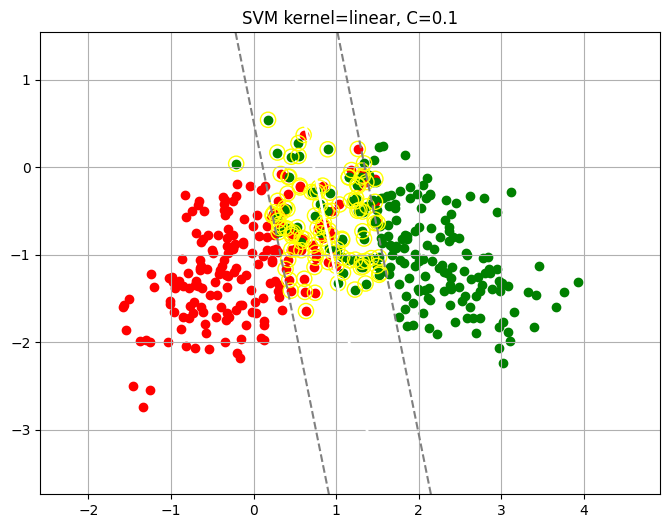


Ядро: poly
C = 0.1
Ошибка: 0.0925
Опорных векторов: 160


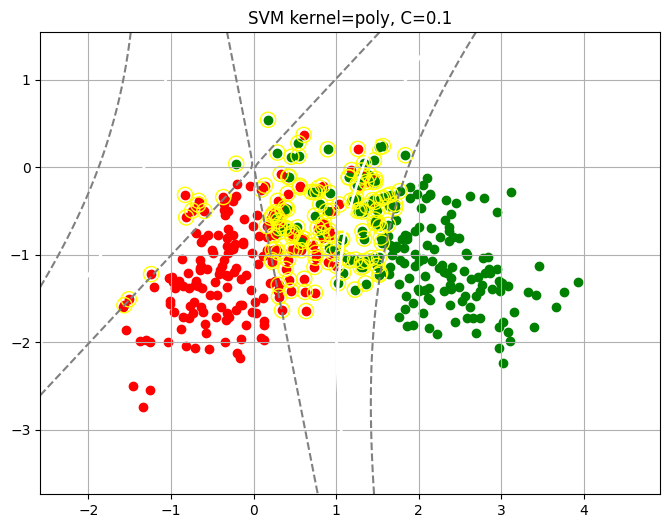


Ядро: rbf
C = 0.1
Ошибка: 0.0825
Опорных векторов: 155


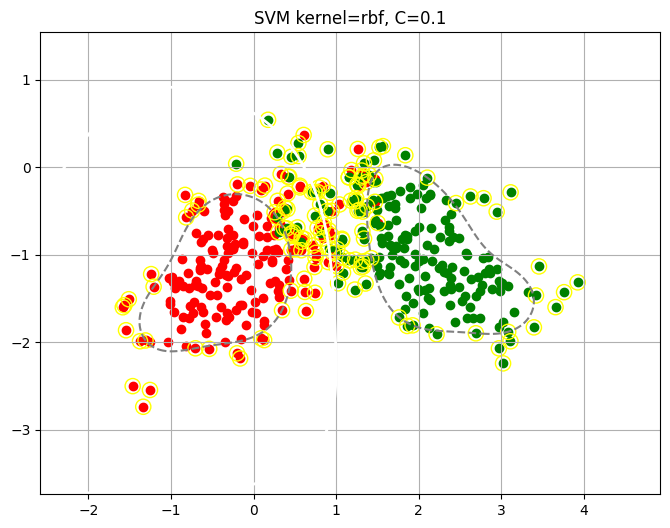


Ядро: sigmoid
C = 0.1
Ошибка: 0.3375
Опорных векторов: 202


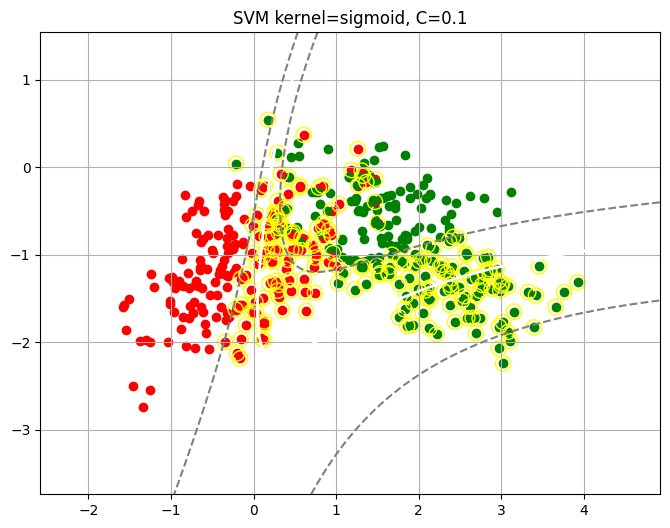


Ядро: linear
C = 1
Ошибка: 0.0925
Опорных векторов: 90


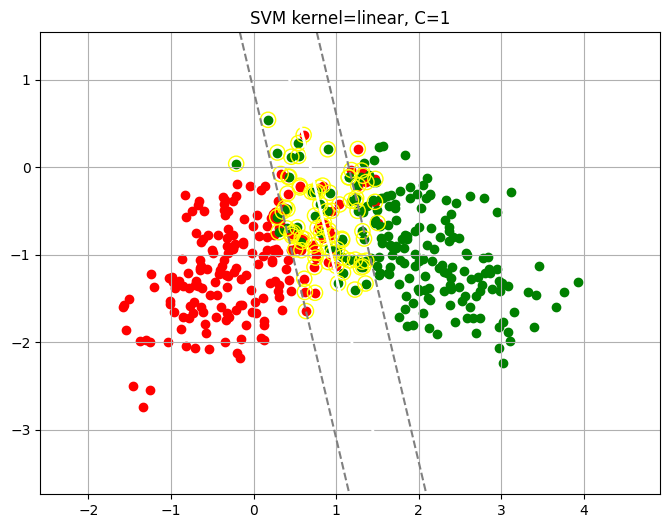


Ядро: poly
C = 1
Ошибка: 0.0875
Опорных векторов: 100


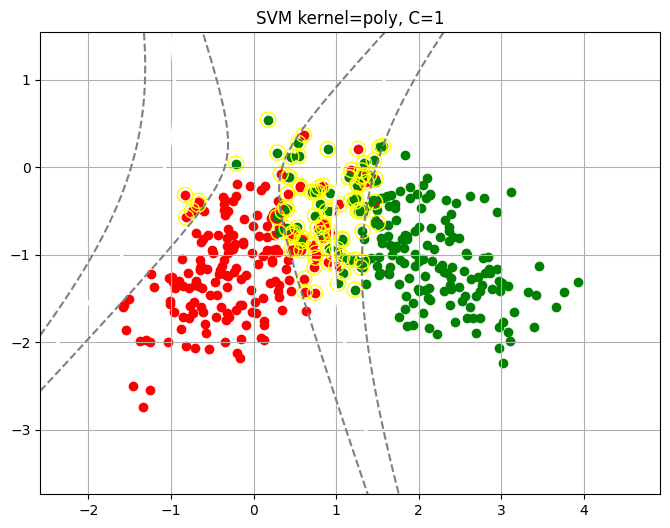


Ядро: rbf
C = 1
Ошибка: 0.0725
Опорных векторов: 94


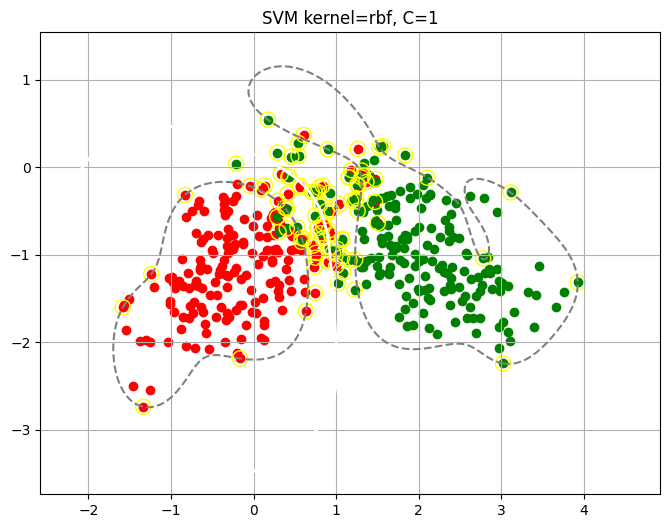


Ядро: sigmoid
C = 1
Ошибка: 0.3975
Опорных векторов: 168


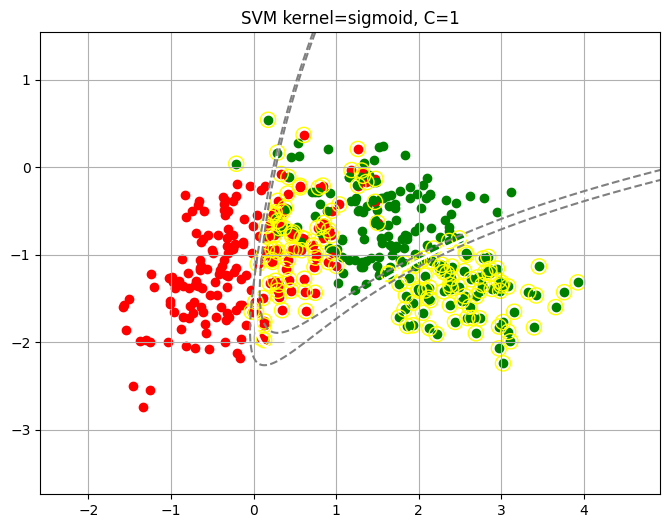


Ядро: linear
C = 10
Ошибка: 0.0925
Опорных векторов: 85


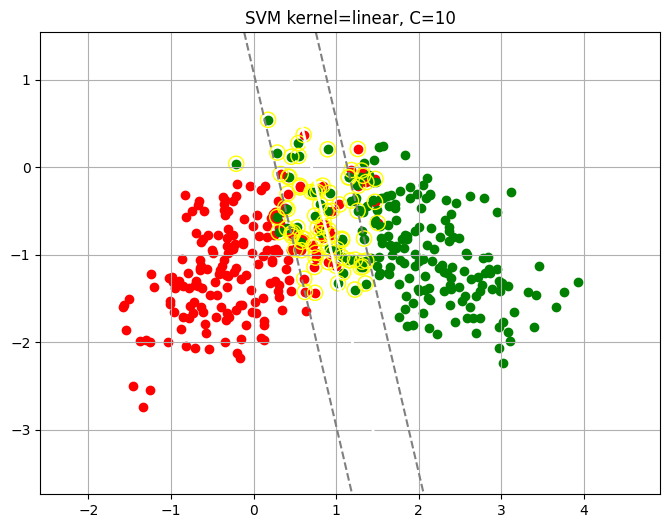


Ядро: poly
C = 10
Ошибка: 0.095
Опорных векторов: 84


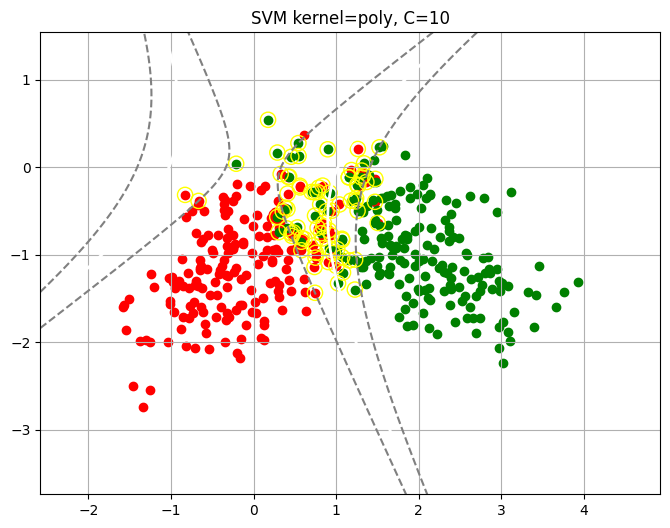


Ядро: rbf
C = 10
Ошибка: 0.0725
Опорных векторов: 88


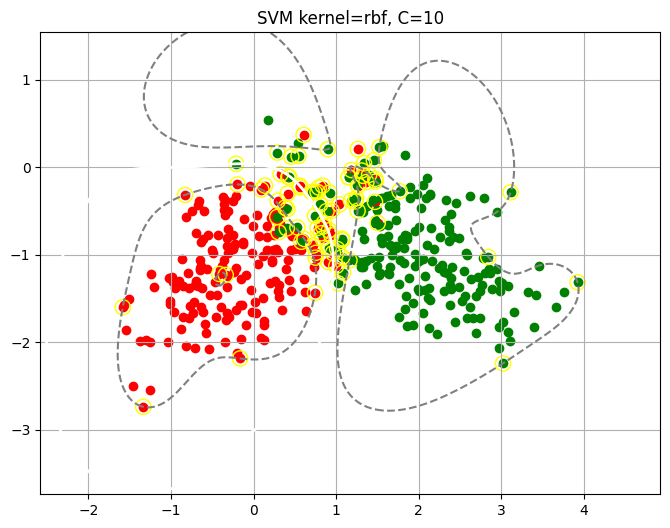


Ядро: sigmoid
C = 10
Ошибка: 0.405
Опорных векторов: 164


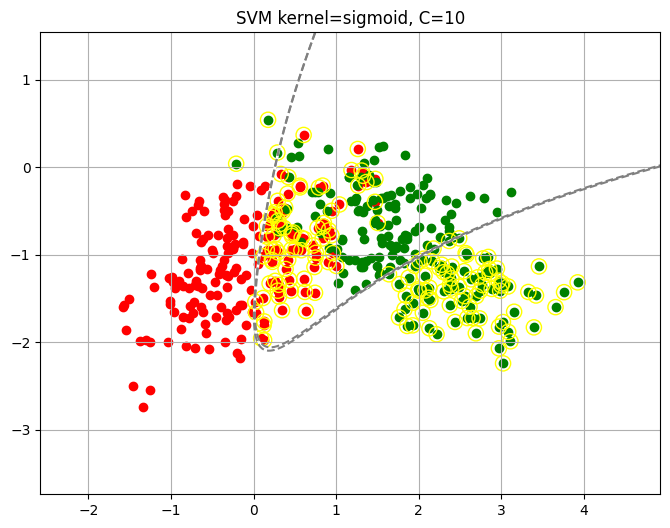

In [24]:
for C in [0.1, 1, 10]:

    for kernel_name, params in kernels:

        print("\n" + "=" * 50)
        print("Ядро:", kernel_name)
        print("C =", C)

        model = SVC(kernel=kernel_name, C=C, **params)
        model.fit(X_soft, y_soft)

        pred = model.predict(X_soft)

        error = np.mean(pred != y_soft)

        print("Ошибка:", error)
        print("Опорных векторов:", len(model.support_vectors_))

        plot_kernel_svm(
            model,
            X_soft,
            y_soft,
            f'SVM kernel={kernel_name}, C={C}'
        )
